# Movie Industry Correlation Analysis — v2

This notebook revisits my original guided-project notebook (`MovieCorrelationProject4.ipynb`, kept unchanged) and fixes the analytical issues I found when reviewing it:

| Issue in v1 | Change in v2 |
|---|---|
| Missing budgets (28%) and gross values were filled with **0**, which distorts correlations | Use only films where both values are known (complete cases) and show how much the zero-fill changed the result |
| Pearson correlation only, on heavily skewed money values | Compare **Pearson** with rank-based **Spearman** correlation |
| Scatter plot axis labels were swapped | Correct labels, log scales for money |
| Text columns converted to arbitrary category codes and correlated | Compare **groups** (median gross by genre) instead |

**Data:** [Movie Industry](https://www.kaggle.com/datasets/danielgrijalvas/movies) by Daniel Grijalva (Kaggle, CC0). Download `movies.csv` into this folder before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")
IMG = Path("images/v2"); IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("movies.csv")
print(f"{len(df):,} films, {df.shape[1]} columns")

7,668 films, 15 columns


## 1. Data quality: how much is missing?

In [2]:
missing = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing[missing > 0].to_frame("missing_%")

,missing_%
budget,28.31
gross,2.46
rating,1.00
company,0.22
runtime,0.05
score,0.04
votes,0.04
country,0.04
writer,0.04
released,0.03


## 2. Analysis dataset: complete cases for money columns

In [3]:
money = df.dropna(subset=["budget", "gross"]).copy()
money = money[(money["budget"] > 0) & (money["gross"] > 0)]
print(f"Films with known budget and gross: {len(money):,} of {len(df):,} ({len(money)/len(df):.1%})")

Films with known budget and gross: 5,436 of 7,668 (70.9%)


## 3. Budget vs gross: how much did the zero-fill change the result?

In [4]:
zero_filled = df.fillna(0)
comparison = pd.DataFrame({
    "method": ["v1: Pearson, missing filled with 0", "v2: Pearson, complete cases", "v2: Spearman, complete cases"],
    "budget_vs_gross": [
        zero_filled["budget"].corr(zero_filled["gross"]),
        money["budget"].corr(money["gross"]),
        money["budget"].corr(money["gross"], method="spearman"),
    ],
    "votes_vs_gross": [
        zero_filled["votes"].corr(zero_filled["gross"]),
        money["votes"].corr(money["gross"]),
        money["votes"].corr(money["gross"], method="spearman"),
    ],
}).round(3)
comparison

,method,budget_vs_gross,votes_vs_gross
0,"v1: Pearson, missing filled with 0",0.750,0.633
1,"v2: Pearson, complete cases",0.740,0.615
2,"v2: Spearman, complete cases",0.694,0.746


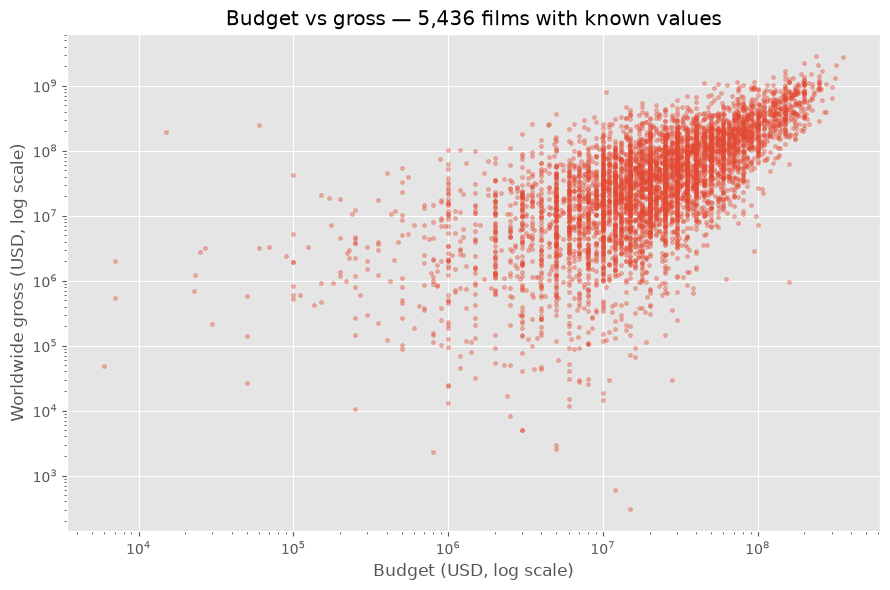

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(money["budget"], money["gross"], s=8, alpha=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Budget (USD, log scale)"); ax.set_ylabel("Worldwide gross (USD, log scale)")
ax.set_title(f"Budget vs gross — {len(money):,} films with known values")
fig.tight_layout(); fig.savefig(IMG / "budget-vs-gross-log.png", dpi=120); plt.show()

## 4. Correlation between numeric variables (Spearman, complete cases)

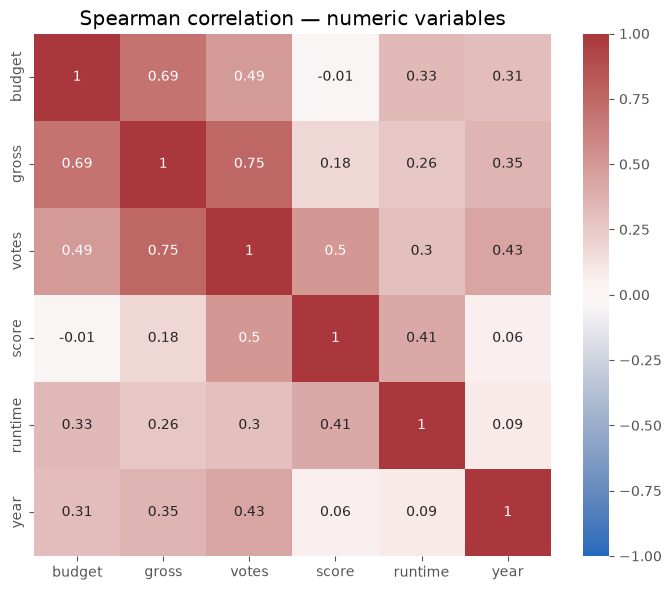

,spearman_with_gross
votes,0.75
budget,0.69
year,0.35
runtime,0.26
score,0.18


In [6]:
numeric = money[["budget", "gross", "votes", "score", "runtime", "year"]]
corr = numeric.corr(method="spearman").round(2)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation — numeric variables")
fig.tight_layout(); fig.savefig(IMG / "spearman-heatmap.png", dpi=120); plt.show()
corr["gross"].drop("gross").sort_values(ascending=False).to_frame("spearman_with_gross")

## 5. Gross by genre (group comparison instead of category codes)

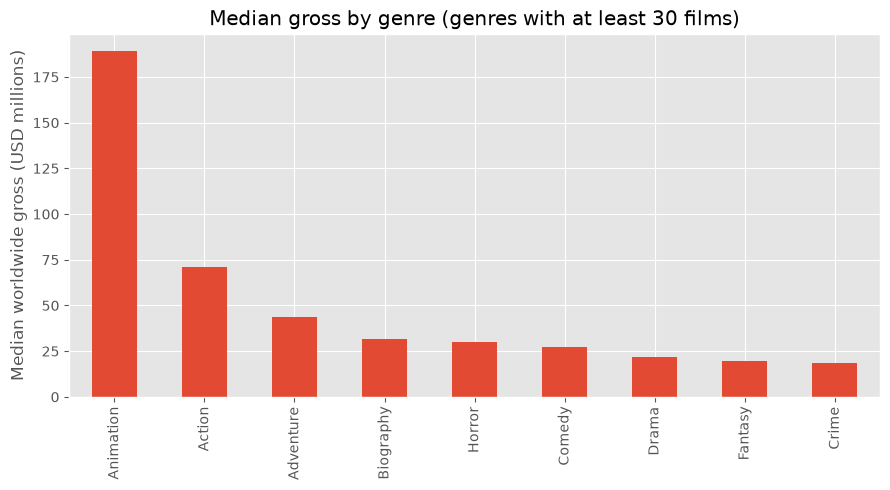

,films,median_gross_musd
genre,,
Animation,278,189.3
Action,1417,71.3
Adventure,327,43.4
Biography,312,31.6
Horror,254,30.0
Comedy,1496,27.4
Drama,869,22.0
Fantasy,42,19.7
Crime,400,18.7


In [7]:
genre = (money.groupby("genre")["gross"]
         .agg(films="count", median_gross="median")
         .query("films >= 30")
         .sort_values("median_gross", ascending=False))
fig, ax = plt.subplots(figsize=(9, 5))
(genre["median_gross"] / 1e6).plot.bar(ax=ax)
ax.set_ylabel("Median worldwide gross (USD millions)"); ax.set_xlabel("")
ax.set_title("Median gross by genre (genres with at least 30 films)")
fig.tight_layout(); fig.savefig(IMG / "median-gross-by-genre.png", dpi=120); plt.show()
genre.assign(median_gross_musd=(genre["median_gross"] / 1e6).round(1)).drop(columns="median_gross")

## 6. Conclusions (from the outputs above)

1. **Zero-filling barely changed the budget–gross Pearson correlation** (0.750 → 0.740), but it was still the wrong method: 28% of films had no budget, and the analysis set shrinks to 5,436 films with both values known.
2. **Rank-based (Spearman) correlation changes the ranking.** Votes are the variable most associated with gross (ρ = 0.75), slightly ahead of budget (ρ = 0.69). Pearson, which is sensitive to a few blockbuster outliers, had put budget first.
3. **Genre matters.** Among genres with at least 30 films, Animation has by far the highest median gross (≈ USD 189 M), followed by Action (≈ USD 71 M).
4. All of these are **associations, not causes**. Votes, in particular, partly reflect how many people saw a film, so they are an outcome of success rather than a driver of it.

**Limitations:** gross values are nominal (not adjusted for inflation), the dataset covers 1980–2020 releases with Kaggle's own coverage, and no significance testing or modelling was done.